# Momentum Model Comparison: `class_IDE` only

This notebook runs the same momentum/type-3 benchmark grid used in `Coupling_example.ipynb`, but only with a local `class_IDE` executable.

It does not import or run `darkin-class`, because only one `classy`/CLASS build should be active in a given environment. Run the darkin-class cases separately in `Coupling_example.ipynb`, then compare these saved class_IDE spectra/ratios.

Matched scan values:
`[0.0, -0.1, -0.5, -1.0, -5.0, -10.0, -100.0, -10000.0]`

Outputs saved here:
- class_IDE LCDM fiducial and scalar momentum scan INI/log/output files
- class_IDE absolute `P(k)` plot
- class_IDE ratio-to-LCDM plot
- tabulated class_IDE spectra and ratios for later cross-environment comparison


In [1]:
import os
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('bmh')
lw = 2.5


In [2]:
# Paths
# Set CLASS_IDE_BINARY in the new environment if the binary is somewhere else, e.g.
# export CLASS_IDE_BINARY=/path/to/class_IDE/class
repo_root = Path.cwd()

def is_runnable_class_binary(path: Path):
    if not path.exists():
        return False
    try:
        # CLASS exits cleanly with no arguments; this also catches wrong-OS binaries.
        subprocess.run([str(path)], capture_output=True, text=True, timeout=2)
        return True
    except (OSError, subprocess.TimeoutExpired):
        return False


if os.environ.get('CLASS_IDE_BINARY'):
    class_ide = Path(os.environ['CLASS_IDE_BINARY'])
    if not is_runnable_class_binary(class_ide):
        raise FileNotFoundError(f"CLASS_IDE_BINARY is not runnable in this environment: {class_ide}")
else:
    class_ide_candidates = [
        Path('/private/tmp/class_IDE_local/class'),
        Path('/Users/elsateixeira/Downloads/class_IDE/class'),
    ]
    class_ide = next((path for path in class_ide_candidates if is_runnable_class_binary(path)), class_ide_candidates[0])

out_dir = Path(os.environ.get('CLASS_IDE_OUT_DIR', 'notebooks/class_IDE_momentum_runs'))
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir = Path('notebooks/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

if not is_runnable_class_binary(class_ide):
    raise FileNotFoundError(
        f"Missing runnable class_IDE binary: {class_ide}. Build class_IDE first or set CLASS_IDE_BINARY."
    )

print('class_IDE binary:', class_ide)
print('output dir:', out_dir)
print('figure dir:', fig_dir)


class_IDE binary: /private/tmp/class_IDE_local/class
output dir: notebooks/class_IDE_momentum_runs
figure dir: notebooks/figures


In [3]:
def write_ini(path: Path, entries: dict):
    lines = [f"{k} = {v}" for k, v in entries.items()]
    path.write_text("\n".join(lines) + "\n")


def run_class(exe: Path, ini: Path):
    log = ini.with_suffix('.log')
    p = subprocess.run([str(exe), str(ini)], capture_output=True, text=True)
    log.write_text((p.stdout or '') + '\n' + (p.stderr or ''))
    if p.returncode != 0:
        tail = '\n'.join(log.read_text().splitlines()[-40:])
        raise RuntimeError(f"Run failed for {ini.name} (exit={p.returncode})\n{tail}")
    return log


def load_pk(path: Path):
    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"Unexpected pk format in {path}")
    return arr[:, 0], arr[:, 1]


def find_pk_for_root(root_value: str):
    root = Path(root_value)
    candidates = sorted(root.parent.glob(root.name + '*pk.dat'))
    candidates = [path for path in candidates if not path.name.endswith('_pk_cb.dat')]
    if not candidates:
        raise FileNotFoundError(f"No P(k) output found for root {root_value}")
    if len(candidates) > 1:
        print('Multiple P(k) outputs found; using first:')
        for candidate in candidates:
            print(' -', candidate)
    return candidates[0]


In [4]:
# class_IDE benchmark settings matching the momentum block in Coupling_example.ipynb.
# In darkin-class these values are named gamma0; in class_IDE the corresponding
# type-3/momentum parameter is scf_veta.
TYPE3_MODE = 'paper2603'

k_scale = [
    0.0001 * 0.67556,
    0.1 * 0.67556,
    0.125 * 0.67556,
    0.01 * 0.67556,
    1.0 * 0.67556,
    0.2 * 0.67556,
    2.0 * 0.67556,
]
output_k = ','.join(str(k) for k in np.sort(k_scale))

# Same scan as Coupling_example.ipynb:type3_gammas
ide_vetas = [0.0, -0.1, -0.5, -1.0, -5.0, -10.0, -100.0, -10000.0]

ide_labels = {
    0.0: r'$v_\eta=0$ scalar',
    -0.1: r'$v_\eta=-0.1$',
    -0.5: r'$v_\eta=-0.5$',
    -1.0: r'$v_\eta=-1.0$',
    -5.0: r'$v_\eta=-5.0$',
    -10.0: r'$v_\eta=-10.0$',
    -100.0: r'$v_\eta=-100$',
    -10000.0: r'$v_\eta=-10^4$',
}

style_cycle = [
    {'ls': '-', 'lw': lw},
    {'ls': '--', 'lw': lw},
    {'ls': '-.', 'lw': lw},
    {'ls': ':', 'lw': lw},
    {'ls': (0, (5, 1)), 'lw': lw},
    {'ls': (0, (3, 1, 1, 1)), 'lw': lw},
    {'ls': (0, (1, 1)), 'lw': lw},
    {'ls': (0, (7, 2)), 'lw': lw},
]
ide_styles = {v: style_cycle[i % len(style_cycle)] for i, v in enumerate(ide_vetas)}

# Baseline common settings copied from Coupling_example common_type3 where class_IDE accepts them.
# For class_IDE the coupled matter is standard CDM, so omega_qcdm -> omega_cdm.
ide_common = {
    'output': 'mPk',
    'omega_b': 0.022032,
    'h': 0.673,
    'N_ncdm': 1,
    'N_ur': 2.0328,
    'm_ncdm': 0.06,
    'T_ncdm': 0.71611,
    'tau_reio': 5.564022e-02,
    'YHe': 2.478407e-01,
    'A_s': 2.215e-9,
    'n_s': 0.9619,
    'P_k_max_h/Mpc': 10.0,
    'z_pk': 0,
    'evolver': 0,
    'gauge': 'synchronous',
    'k_output_values': output_k,
    'write background': 'yes',
    'z_max_pk': 1000.0,
    'l_switch_limber_for_nc_local_over_z': 1000,
    'l_switch_limber_for_nc_los_over_z': 1000,
    'start_small_k_at_tau_c_over_tau_h': 1e-5,
    # Older class_IDE starts the background later than darkin-class; 0.004 is the
    # smallest safe value for the matched large-k scan on this build.
    'start_large_k_at_tau_h_over_tau_k': 0.004,
    'format': 'class',
}

ide_lcdm = dict(ide_common)
ide_lcdm.update({
    # True LCDM fiducial, matching Coupling_example.lcdm_type3_params():
    # no Omega_scf/Omega_Lambda/Omega_fld entries, so Lambda closes the budget.
    'omega_cdm': 0.12038,
    'root': str(out_dir / 'classide_lcdm_'),
})


def classide_type3_params(veta):
    p = dict(ide_common)
    p.update({
        'Omega_Lambda': 0.0,
        'Omega_fld': 0.0,
        'Omega_scf': -1,
        'attractor_ic_scf': 'no',
        # class_IDE scf_parameters = lambda, alpha, A, B, phi_ini, phi_prime_ini
        # Matching darkin-class: scf_lambda=0.5, scf_V0=0, phi_ini=1e-4, phi_prime_ini=0.
        'scf_parameters': '0.5, 0.0, 0.0, 0.0, 1e-4, 0.0',
        'scf_tuning_index': 2,
        'a_ini_over_a_today_default': '1.e-9',
        'omega_cdm': 0.12038,
        'scf_veta': veta,
        'root': str(out_dir / f'classide_veta_{slug_value(veta)}_'),
    })
    return p


def slug_value(value):
    if value == 0:
        return '0'
    text = f'{value:g}'.replace('-', 'm').replace('+', 'p').replace('.', 'p')
    return text


In [5]:
# Run class_IDE LCDM plus the full momentum scan from Coupling_example
ini_lcdm = out_dir / 'classide_lcdm.ini'
write_ini(ini_lcdm, ide_lcdm)
run_class(class_ide, ini_lcdm)
pk_lcdm = find_pk_for_root(ide_lcdm['root'])

ide_runs = {}
ide_failures = {}
for veta in ide_vetas:
    params = classide_type3_params(veta)
    ini = out_dir / f'classide_veta_{slug_value(veta)}.ini'
    write_ini(ini, params)
    try:
        run_class(class_ide, ini)
        pk_file = find_pk_for_root(params['root'])
        ide_runs[veta] = {'params': params, 'ini': ini, 'pk': pk_file}
        print(f'veta={veta:g}: produced {pk_file}')
    except Exception as err:
        ide_failures[veta] = err
        print(f'veta={veta:g}: FAILED {err}')

if ide_failures:
    print('Warning: some class_IDE momentum cases failed:')
    for veta, err in ide_failures.items():
        print(f'  veta={veta:g}: {err}')

if not ide_runs:
    raise RuntimeError('No class_IDE momentum cases succeeded.')

print('Produced class_IDE LCDM file:')
print(' -', pk_lcdm)
print('Successful class_IDE scan values:', list(ide_runs.keys()))


veta=0: produced notebooks/class_IDE_momentum_runs/classide_veta_0_pk.dat
veta=-0.1: produced notebooks/class_IDE_momentum_runs/classide_veta_m0p1_pk.dat
veta=-0.5: produced notebooks/class_IDE_momentum_runs/classide_veta_m0p5_pk.dat
veta=-1: produced notebooks/class_IDE_momentum_runs/classide_veta_m1_pk.dat
veta=-5: produced notebooks/class_IDE_momentum_runs/classide_veta_m5_pk.dat
veta=-10: produced notebooks/class_IDE_momentum_runs/classide_veta_m10_pk.dat
veta=-100: produced notebooks/class_IDE_momentum_runs/classide_veta_m100_pk.dat
veta=-10000: produced notebooks/class_IDE_momentum_runs/classide_veta_m10000_pk.dat
Produced class_IDE LCDM file:
 - notebooks/class_IDE_momentum_runs/classide_lcdm_pk.dat
Successful class_IDE scan values: [0.0, -0.1, -0.5, -1.0, -5.0, -10.0, -100.0, -10000.0]


In [6]:
# Load class_IDE outputs and compute ratios.
# The true-LCDM run is kept to match Coupling_example, but some older class_IDE
# builds write an all-zero LCDM P(k). In that case we skip LCDM ratios and use
# the scalar veta=0 run as the class_IDE-internal reference.
k_lcdm, p_lcdm = load_pk(pk_lcdm)
lcdm_is_valid = np.all(np.isfinite(p_lcdm)) and np.any(p_lcdm > 0.0)

if not lcdm_is_valid:
    print('Warning: class_IDE LCDM P(k) is zero/non-finite in this build; skipping LCDM ratios.')
    print('         The scalar veta=0 run will still be used as the internal class_IDE reference.')

pk_models = {}
ratio_to_lcdm = {}
ratio_to_scalar = {}

p_scalar = None
if 0.0 in ide_runs:
    k_scalar, p_scalar_raw = load_pk(ide_runs[0.0]['pk'])
    p_scalar = np.interp(k_lcdm, k_scalar, p_scalar_raw)
    scalar_is_valid = np.all(np.isfinite(p_scalar)) and np.any(p_scalar > 0.0)
else:
    scalar_is_valid = False

for veta, run in ide_runs.items():
    k_v, p_v = load_pk(run['pk'])
    p_interp = np.interp(k_lcdm, k_v, p_v)
    pk_models[veta] = p_interp

    if lcdm_is_valid:
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_to_lcdm[veta] = p_interp / p_lcdm
    else:
        ratio_to_lcdm[veta] = np.full_like(p_interp, np.nan)

    if scalar_is_valid:
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_to_scalar[veta] = p_interp / p_scalar

# Save a single table with all spectra and LCDM ratios. If the local class_IDE
# LCDM output is zero, the LCDM ratio columns are NaN by construction.
columns = [k_lcdm, p_lcdm]
headers = ['k_h_per_Mpc', 'P_LCDM']
for veta in ide_vetas:
    if veta not in pk_models:
        continue
    columns.append(pk_models[veta])
    columns.append(ratio_to_lcdm[veta])
    headers.append(f'P_veta_{slug_value(veta)}')
    headers.append(f'ratio_to_LCDM_veta_{slug_value(veta)}')

ratio_file = out_dir / 'classIDE_momentum_scan_to_LCDM.dat'
np.savetxt(ratio_file, np.column_stack(columns), header=' '.join(headers))

if lcdm_is_valid:
    print('class_IDE ratio-to-LCDM summaries:')
    for veta in ide_vetas:
        if veta not in ratio_to_lcdm:
            continue
        r = ratio_to_lcdm[veta]
        finite = r[np.isfinite(r)]
        if finite.size == 0:
            continue
        print(f"veta={veta:g}: min={np.nanmin(finite):.6f}, max={np.nanmax(finite):.6f}")
else:
    print('class_IDE LCDM ratio summaries skipped because P_LCDM is not usable.')

if scalar_is_valid:
    print('class_IDE ratio-to-scalar-veta=0 summaries:')
    for veta in ide_vetas:
        if veta not in ratio_to_scalar:
            continue
        r = ratio_to_scalar[veta]
        finite = r[np.isfinite(r)]
        if finite.size == 0:
            continue
        print(f"veta={veta:g}: min={np.nanmin(finite):.6f}, max={np.nanmax(finite):.6f}")
else:
    print('No usable scalar veta=0 reference was produced.')

print('saved scan table:', ratio_file)
for kk in [1e-3, 1e-2, 1e-1, 1.0, 5.0]:
    i = np.argmin(np.abs(k_lcdm - kk))
    values = []
    for veta in ide_vetas:
        if veta in ratio_to_lcdm and lcdm_is_valid:
            values.append(f"{veta:g}:{ratio_to_lcdm[veta][i]:.6f}")
        elif veta in ratio_to_scalar and scalar_is_valid:
            values.append(f"{veta:g}:{ratio_to_scalar[veta][i]:.6f}")
    ref = 'P/P_LCDM' if lcdm_is_valid else 'P/P_veta0'
    print(f"k={k_lcdm[i]:.6e} ({ref})  " + '  '.join(values))


         The scalar veta=0 run will still be used as the internal class_IDE reference.
class_IDE LCDM ratio summaries skipped because P_LCDM is not usable.
class_IDE ratio-to-scalar-veta=0 summaries:
veta=0: min=1.000000, max=1.000000
veta=-0.1: min=0.998089, max=1.001071
veta=-0.5: min=0.994460, max=1.003185
veta=-1: min=0.992737, max=1.004230
veta=-5: min=0.990331, max=1.006042
veta=-10: min=0.989913, max=1.006938
veta=-100: min=0.989505, max=1.009094
veta=-10000: min=0.989460, max=1.010246
saved scan table: notebooks/class_IDE_momentum_runs/classIDE_momentum_scan_to_LCDM.dat
k=1.049799e-03 (P/P_veta0)  0:1.000000  -0.1:0.999875  -0.5:1.000871  -1:1.002262  -5:1.005968  -10:1.006913  -100:1.007947  -10000:1.008074
k=1.003804e-02 (P/P_veta0)  0:1.000000  -0.1:0.998551  -0.5:0.995870  -1:0.994666  -5:0.993594  -10:0.994224  -100:1.003536  -10000:1.010085
k=1.003804e-01 (P/P_veta0)  0:1.000000  -0.1:0.998519  -0.5:0.995738  -1:0.994433  -5:0.992636  -10:0.992333  -100:0.992176  -10000:1

Skipping LCDM line in absolute plot because class_IDE wrote P_LCDM=0.


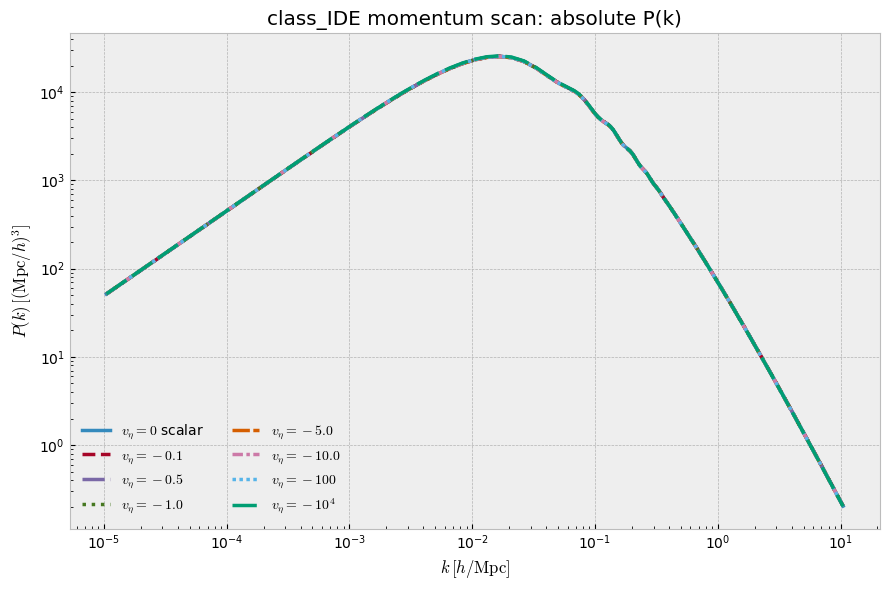

Skipping ratio-to-LCDM plot because class_IDE wrote P_LCDM=0.


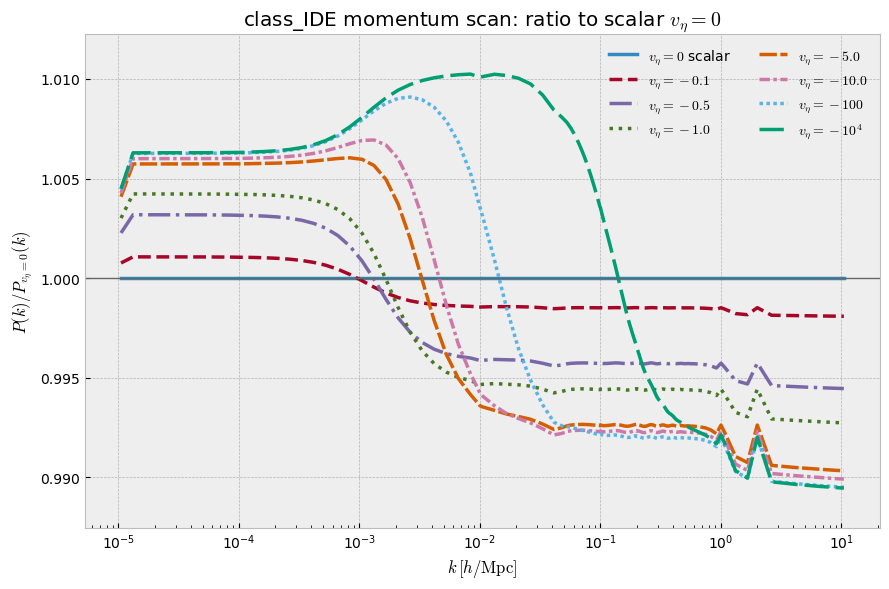

In [7]:
# class_IDE-only plots matching the momentum cases in Coupling_example
plt.figure(figsize=(9, 6))
if lcdm_is_valid:
    plt.loglog(k_lcdm, p_lcdm, '-', lw=1.8, color='k', label='LCDM fiducial')
else:
    print('Skipping LCDM line in absolute plot because class_IDE wrote P_LCDM=0.')

for veta in ide_vetas:
    if veta not in pk_models:
        continue
    plt.loglog(k_lcdm, pk_models[veta], label=ide_labels.get(veta, rf'$v_\eta={veta:g}$'), **ide_styles[veta])
plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k)\,[(\mathrm{Mpc}/h)^3]$')
plt.title('class_IDE momentum scan: absolute P(k)')
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(fig_dir / 'momentum_classIDE_scan_pk.png', dpi=180)
plt.show()

if lcdm_is_valid:
    finite_ratios = [r[np.isfinite(r)] for r in ratio_to_lcdm.values()]
    finite_ratios = [r for r in finite_ratios if r.size > 0]
    ratio_min = min([1.0] + [float(np.min(r)) for r in finite_ratios])
    ratio_max = max([1.0] + [float(np.max(r)) for r in finite_ratios])

    plt.figure(figsize=(9, 6))
    for veta in ide_vetas:
        if veta not in ratio_to_lcdm:
            continue
        plt.semilogx(k_lcdm, ratio_to_lcdm[veta], label=ide_labels.get(veta, rf'$v_\eta={veta:g}$'), **ide_styles[veta])
    plt.axhline(1.0, color='0.4', lw=1.0)
    plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
    plt.ylabel(r'$P(k)/P_{\rm LCDM}(k)$')
    plt.title('class_IDE momentum scan: ratio to LCDM')
    pad = max(0.002, 0.05 * (ratio_max - ratio_min))
    plt.ylim(ratio_min - pad, ratio_max + pad)
    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.savefig(fig_dir / 'momentum_classIDE_scan_ratio_LCDM.png', dpi=180)
    plt.show()
else:
    print('Skipping ratio-to-LCDM plot because class_IDE wrote P_LCDM=0.')

if ratio_to_scalar:
    finite_ratios = [r[np.isfinite(r)] for r in ratio_to_scalar.values()]
    finite_ratios = [r for r in finite_ratios if r.size > 0]
    ratio_min = min([1.0] + [float(np.min(r)) for r in finite_ratios])
    ratio_max = max([1.0] + [float(np.max(r)) for r in finite_ratios])

    plt.figure(figsize=(9, 6))
    for veta in ide_vetas:
        if veta not in ratio_to_scalar:
            continue
        plt.semilogx(k_lcdm, ratio_to_scalar[veta], label=ide_labels.get(veta, rf'$v_\eta={veta:g}$'), **ide_styles[veta])
    plt.axhline(1.0, color='0.4', lw=1.0)
    plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$')
    plt.ylabel(r'$P(k)/P_{v_\eta=0}(k)$')
    plt.title('class_IDE momentum scan: ratio to scalar $v_\eta=0$')
    pad = max(0.002, 0.05 * (ratio_max - ratio_min))
    plt.ylim(ratio_min - pad, ratio_max + pad)
    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.savefig(fig_dir / 'momentum_classIDE_scan_ratio_scalar0.png', dpi=180)
    plt.show()


## Exact figure templates for arXiv:1604.04222

These cells reproduce the structure of Figs. 1--3 from Pourtsidou & Tram (arXiv:1604.04222) using the local class_IDE binary:

- Fig. 1: absolute CMB TT and total matter power spectra for beta = 0, 0.1, -0.5.
- Fig. 2: CMB TT and matter-power ratios to the beta = 0 uncoupled quintessence model for the negative-beta scan.
- Fig. 3: evolution of 1 + w_phi versus conformal time.

This block follows the shipped `class_IDE/IDE_parameters.ini` specification, because that is what reproduces the published matter-spectrum amplitude: fixed `h = 0.673`, `output = tCl, mPk, pCl, dTk`, and the HMcode/OWLS-AGN nonlinear settings.


In [8]:
# arXiv:1604.04222 figure reproduction settings.
# class_IDE implements gamma(Z)=beta Z^2 with beta stored as scf_veta.
# These settings intentionally follow /private/tmp/class_IDE_local/IDE_parameters.ini
# rather than the earlier theta_s-normalized notebook block, because the shipped
# code specification is what gives the published ~15% matter-power differences.
paper1604_fig1_betas = [0.0, 0.1, -0.5]
paper1604_scan_betas = [0.0, -1e-2, -1e-1, -1.0, -1e1, -1e2, -1e3, -1e4, -1e5, -1e6]
paper1604_betas = list(dict.fromkeys(paper1604_fig1_betas + paper1604_scan_betas))

# Fig. 1--2 in the paper only show the matter spectrum to k~1.
# Keep P_k_max_h/Mpc=10 for CLASS internals, but summarize/plot this range.
PAPER1604_K_MAX_PLOT = 1.0

paper1604_common = {
    'Omega_Lambda': 0.0,
    'Omega_fld': 0.0,
    'Omega_scf': -1,
    'attractor_ic_scf': 'no',
    'h': 0.673,
    'write warnings': 'yes',
    # class_IDE order: lambda, alpha, A, B, phi_ini, phi_prime_ini.
    'scf_parameters': '0.5, 0.0, 0.0, 0.0, 1e-4, 0.0',
    'scf_tuning_index': 2,
    'a_ini_over_a_today_default': '1.e-9',
    # Match the shipped figure-production style. In this old CLASS branch,
    # requesting tCl/pCl changes the spectra pipeline used for the saved mPk.
    'output':'tCl,pCl,dCl,lCl,mPk,mTk',
    'non linear': 'hmcode',
    'feedback model': 'owls_agn',
    'lensing': 'yes',
    'P_k_max_h/Mpc': 10.0,
    'write background': 'yes',
    'k_output_values': '1e-7, 1e-4, 1e-1',
    'root': str(out_dir / 'classide_1604_exact_placeholder_'),
    'format': 'class',
    'input_verbose': 1,
    'background_verbose': 1,
    'thermodynamics_verbose': 1,
    'perturbations_verbose': 1,
    'transfer_verbose': 1,
    'primordial_verbose': 1,
    'spectra_verbose': 1,
    'nonlinear_verbose': 1,
    'lensing_verbose': 1,
    'output_verbose': 1,
}


def paper1604_beta_slug(beta):
    if beta == 0:
        return '0'
    text = f'{beta:g}'
    return text.replace('-', 'm').replace('+', 'p').replace('.', 'p').replace('e', 'e')


def paper1604_label(beta):
    if beta == 0:
        return r'$\beta=0$'
    abs_beta = abs(beta)
    exp = np.log10(abs_beta) if abs_beta > 0 else None
    if exp is not None and np.isclose(exp, round(exp)):
        sign = '-' if beta < 0 else ''
        return rf'$\beta={sign}10^{{{int(round(exp))}}}$'
    return rf'$\beta={beta:g}$'


paper1604_fig1_styles = {
    0.0: {'ls': '-', 'lw': 2.0, 'color': 'k'},
    0.1: {'ls': '--', 'lw': 2.0, 'color': 'tab:red'},
    -0.5: {'ls': '-.', 'lw': 2.0, 'color': 'tab:blue'},
}

paper1604_scan_colors = plt.cm.plasma(np.linspace(0.08, 0.92, len(paper1604_scan_betas)))


def paper1604_scan_style(beta):
    i = paper1604_scan_betas.index(beta) if beta in paper1604_scan_betas else 0
    if beta == 0:
        return {'ls': '-', 'lw': 2.0, 'color': 'k'}
    return {'ls': '-', 'lw': 1.7, 'color': paper1604_scan_colors[i]}


def classide_paper1604_params(beta):
    p = dict(paper1604_common)
    p.update({
        'scf_veta': beta,
        'root': str(out_dir / f'classide_1604_exact_beta_{paper1604_beta_slug(beta)}_'),
    })
    return p


def find_classide_output_for_root(root_value: str, suffix: str):
    root = Path(root_value)
    candidates = sorted(root.parent.glob(root.name + suffix))
    if not candidates:
        raise FileNotFoundError(f'No output *{suffix} found for root {root_value}')
    if len(candidates) > 1:
        print(f'Multiple *{suffix} outputs found; using first:')
        for candidate in candidates:
            print(' -', candidate)
    return candidates[0]


def load_cl_tt(path: Path):
    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f'Unexpected C_l format in {path}')
    # class_IDE format=class stores l(l+1)C_l/(2pi) in column 2.
    return arr[:, 0], arr[:, 1]


def h_from_background(path: Path):
    arr = np.loadtxt(path)
    z = arr[:, 0]
    H_over_c = arr[:, 3]  # H/c in 1/Mpc in CLASS background output.
    idx = int(np.argmin(np.abs(z)))
    return H_over_c[idx] * 299792.458 / 100.0


def load_pk_physical(run):
    k_h, p_h = load_pk(run['pk'])
    h_run = h_from_background(run['background'])
    # pk.dat header: k in h/Mpc and P in (Mpc/h)^3.
    return k_h * h_run, p_h / h_run**3


def load_wphi(run):
    arr = np.loadtxt(run['background'])
    tau = arr[:, 2]
    # Header columns are 1-based. In this class_IDE background table:
    # 14:(.)rho_scf and 15:(.)p_scf, so use zero-based 13 and 14.
    rho_scf = arr[:, 13]
    p_scf = arr[:, 14]
    with np.errstate(divide='ignore', invalid='ignore'):
        w_phi = p_scf / rho_scf
    return tau, w_phi


In [9]:
# Run the arXiv:1604.04222 beta cases in class_IDE.
paper1604_runs = {}
paper1604_failures = {}

for beta in paper1604_betas:
    params = classide_paper1604_params(beta)
    ini = out_dir / f'classide_1604_exact_beta_{paper1604_beta_slug(beta)}.ini'
    write_ini(ini, params)
    try:
        run_class(class_ide, ini)
        paper1604_runs[beta] = {
            'params': params,
            'ini': ini,
            'pk': find_classide_output_for_root(params['root'], 'pk.dat'),
            'cl': find_classide_output_for_root(params['root'], 'cl.dat'),
            'background': find_classide_output_for_root(params['root'], 'background.dat'),
        }
        print(f'beta={beta:g}: produced pk/cl/background outputs')
    except Exception as err:
        paper1604_failures[beta] = err
        print(f'beta={beta:g}: FAILED {err}')

if paper1604_failures:
    print('Warning: some arXiv:1604.04222 cases failed and will be skipped:')
    for beta, err in paper1604_failures.items():
        print(f'  beta={beta:g}: {err}')

if 0.0 not in paper1604_runs:
    raise RuntimeError('The beta=0 reference run is required for Figs. 2 and 3.')


beta=0: produced pk/cl/background outputs
beta=0.1: produced pk/cl/background outputs
beta=-0.5: produced pk/cl/background outputs
beta=-0.01: produced pk/cl/background outputs
beta=-0.1: produced pk/cl/background outputs
beta=-1: produced pk/cl/background outputs
beta=-10: produced pk/cl/background outputs
beta=-100: produced pk/cl/background outputs
beta=-1000: produced pk/cl/background outputs
beta=-10000: produced pk/cl/background outputs
beta=-100000: produced pk/cl/background outputs
beta=-1e+06: produced pk/cl/background outputs


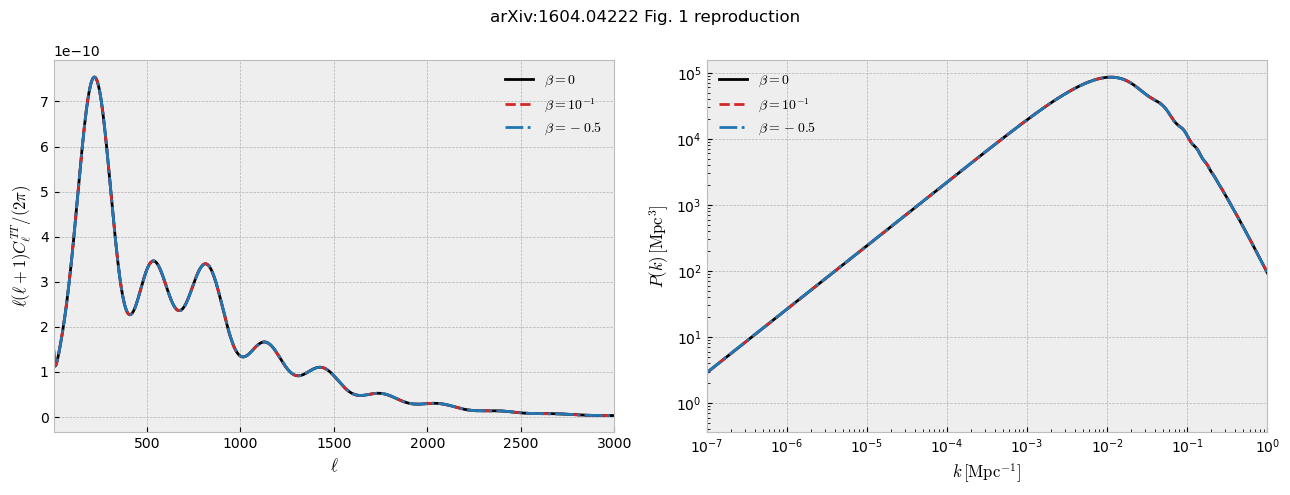

beta=0: plotted k<= 1  min=1.000000, max=1.000000, maxdiff=0.00%
beta=-0.01: plotted k<= 1  min=0.999814, max=1.000130, maxdiff=0.02%
beta=-0.1: plotted k<= 1  min=0.998483, max=1.001094, maxdiff=0.15%
beta=-1: plotted k<= 1  min=0.994331, max=1.004316, maxdiff=0.57%
beta=-10: plotted k<= 1  min=0.992183, max=1.007074, maxdiff=0.78%
beta=-100: plotted k<= 1  min=0.991875, max=1.009234, maxdiff=0.92%
beta=-1000: plotted k<= 1  min=0.991869, max=1.010052, maxdiff=1.01%
beta=-10000: plotted k<= 1  min=0.992138, max=1.010322, maxdiff=1.03%
beta=-100000: plotted k<= 1  min=0.995154, max=1.010425, maxdiff=1.04%
beta=-1e+06: plotted k<= 1  min=1.006050, max=1.010448, maxdiff=1.04%


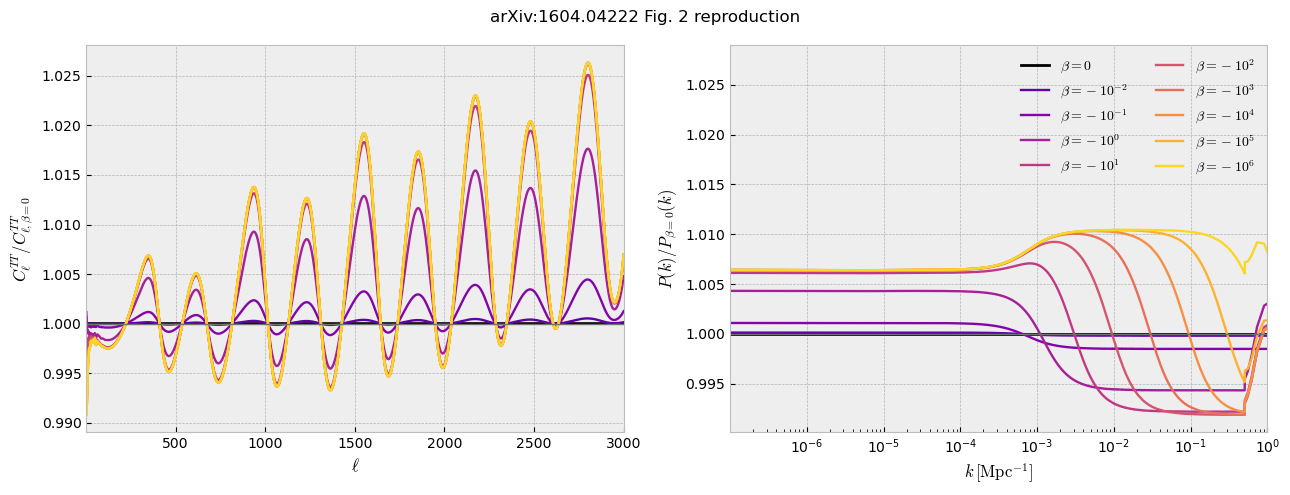

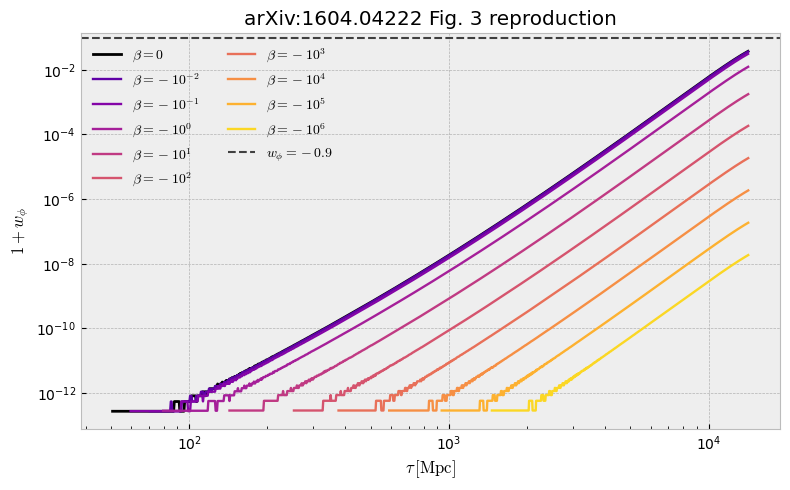

Saved: notebooks/figures/momentum_classIDE_1604_exact_fig1.png
Saved: notebooks/figures/momentum_classIDE_1604_exact_fig2.png
Saved: notebooks/figures/momentum_classIDE_1604_exact_fig3.png
Saved: notebooks/class_IDE_momentum_runs/classIDE_momentum_1604_exact_fig2_ratios.dat


In [10]:
# Reproduce Figs. 1--3 from arXiv:1604.04222 as combined paper-style figures.
# -----------------------------------------------------------------------------
# Fig. 1: absolute TT and total matter power spectra for beta=0, 0.1, -0.5.
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

for beta in paper1604_fig1_betas:
    if beta not in paper1604_runs:
        continue
    style = paper1604_fig1_styles[beta]
    ell, tt = load_cl_tt(paper1604_runs[beta]['cl'])
    mask = (ell >= 2) & (ell <= 3000)
    axs[0].plot(ell[mask], tt[mask], label=paper1604_label(beta), **style)

    k_phys, p_phys = load_pk_physical(paper1604_runs[beta])
    axs[1].loglog(k_phys, p_phys, label=paper1604_label(beta), **style)

axs[0].set_xlim(2, 3000)
axs[0].set_xlabel(r'$\ell$')
axs[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/(2\pi)$')
axs[0].legend(frameon=False)

axs[1].set_xlim(k_phys[k_phys > 0].min(), PAPER1604_K_MAX_PLOT)
axs[1].set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
axs[1].set_ylabel(r'$P(k)\,[\mathrm{Mpc}^{3}]$')
axs[1].legend(frameon=False)

fig.suptitle('arXiv:1604.04222 Fig. 1 reproduction')
fig.tight_layout()
fig1_file = fig_dir / 'momentum_classIDE_1604_exact_fig1.png'
fig.savefig(fig1_file, dpi=180)
plt.show()

# -----------------------------------------------------------------------------
# Fig. 2: TT and P(k) ratios relative to uncoupled quintessence beta=0.
ell_ref, tt_ref = load_cl_tt(paper1604_runs[0.0]['cl'])
k_ref, p_ref = load_pk_physical(paper1604_runs[0.0])

ratio_columns = [k_ref, p_ref]
ratio_headers = ['k_1_per_Mpc', 'P_beta_0_Mpc3']

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

for beta in paper1604_scan_betas:
    if beta not in paper1604_runs:
        continue
    style = paper1604_scan_style(beta)

    ell_beta, tt_beta = load_cl_tt(paper1604_runs[beta]['cl'])
    tt_interp = np.interp(ell_ref, ell_beta, tt_beta)
    with np.errstate(divide='ignore', invalid='ignore'):
        tt_ratio = tt_interp / tt_ref
    ell_mask = (ell_ref >= 2) & (ell_ref <= 3000) & np.isfinite(tt_ratio)
    axs[0].plot(ell_ref[ell_mask], tt_ratio[ell_mask], label=paper1604_label(beta), **style)

    k_beta, p_beta = load_pk_physical(paper1604_runs[beta])
    p_interp = np.interp(k_ref, k_beta, p_beta)
    with np.errstate(divide='ignore', invalid='ignore'):
        pk_ratio = p_interp / p_ref
    axs[1].semilogx(k_ref, pk_ratio, label=paper1604_label(beta), **style)

    ratio_columns.extend([p_interp, pk_ratio])
    ratio_headers.extend([f'P_beta_{paper1604_beta_slug(beta)}_Mpc3', f'ratio_beta_{paper1604_beta_slug(beta)}'])

    paper_mask = (k_ref <= PAPER1604_K_MAX_PLOT) & np.isfinite(pk_ratio)
    if np.any(paper_mask):
        paper_ratio = pk_ratio[paper_mask]
        print(
            f'beta={beta:g}: plotted k<= {PAPER1604_K_MAX_PLOT:g}  '
            f'min={paper_ratio.min():.6f}, max={paper_ratio.max():.6f}, '
            f'maxdiff={np.max(np.abs(paper_ratio - 1.0))*100:.2f}%'
        )

axs[0].axhline(1.0, color='0.45', lw=1.0)
axs[0].set_xlim(2, 3000)
axs[0].set_xlabel(r'$\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}/C_{\ell,\beta=0}^{TT}$')

axs[1].axhline(1.0, color='0.45', lw=1.0)
axs[1].set_xlim(k_ref[k_ref > 0].min(), PAPER1604_K_MAX_PLOT)
axs[1].set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
axs[1].set_ylabel(r'$P(k)/P_{\beta=0}(k)$')
axs[1].legend(frameon=False, ncol=2)

fig.suptitle('arXiv:1604.04222 Fig. 2 reproduction')
fig.tight_layout()
fig2_file = fig_dir / 'momentum_classIDE_1604_exact_fig2.png'
fig.savefig(fig2_file, dpi=180)
plt.show()

paper1604_ratio_file = out_dir / 'classIDE_momentum_1604_exact_fig2_ratios.dat'
np.savetxt(paper1604_ratio_file, np.column_stack(ratio_columns), header=' '.join(ratio_headers))

# -----------------------------------------------------------------------------
# Fig. 3: scalar-field equation-of-state evolution.
fig, ax = plt.subplots(figsize=(8, 5))
for beta in paper1604_scan_betas:
    if beta not in paper1604_runs:
        continue
    tau, w_phi = load_wphi(paper1604_runs[beta])
    one_plus_w = 1.0 + w_phi
    mask = np.isfinite(one_plus_w) & (one_plus_w > 0.0)
    if not np.any(mask):
        continue
    ax.loglog(tau[mask], one_plus_w[mask], label=paper1604_label(beta), **paper1604_scan_style(beta))

ax.axhline(0.1, color='0.25', lw=1.5, ls='--', label=r'$w_\phi=-0.9$')
ax.set_xlabel(r'$\tau\,[\mathrm{Mpc}]$')
ax.set_ylabel(r'$1+w_\phi$')
ax.legend(frameon=False, ncol=2)
ax.set_title('arXiv:1604.04222 Fig. 3 reproduction')
fig.tight_layout()
fig3_file = fig_dir / 'momentum_classIDE_1604_exact_fig3.png'
fig.savefig(fig3_file, dpi=180)
plt.show()

print('Saved:', fig1_file)
print('Saved:', fig2_file)
print('Saved:', fig3_file)
print('Saved:', paper1604_ratio_file)
